# Portada

**Universidad Autonoma de Nuevo Leon**

**Maestria de Ciencia de Datos**

**Aprendizaje Automatico**

Irving Daniel Estrada Lopez

Alumnos:
* Andrea Linette Mezquita Gomez
* Carlos Enrique Cepeda Fuentes
* Miguel Alejandro Blanco Rios

# Librerias

In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from sklearn.preprocessing import FunctionTransformer, PowerTransformer, StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from optuna import logging as optuna_logging
from optuna import samplers
from optuna import create_study
from sklearn.model_selection import cross_val_score

from sklearn.decomposition import PCA


# Carga de Datos

In [4]:
# --- Primer dataset (cronologico de contenido) ---
online_retail_ii = pd.read_excel(r"..\data\raw\online_retail_ii.xlsx")

online_retail_ii.rename(columns={
    "Price" : "UnitPrice",
    "Customer ID" : "CustomerID"
}, inplace=True)

print(online_retail_ii.shape)
online_retail_ii.head(5)

(525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
# --- Segundo dataset (cronologico de contenido) ---
online_retail = pd.read_excel(r"..\data\raw\online_retail.xlsx")

online_retail.rename(columns={
    "InvoiceNo" : "Invoice"
}, inplace=True)

print(online_retail.shape)
online_retail.head(5)

(541909, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Procesamiento de Datos

In [6]:
# Se omiten las ordenes de compra que ya estan en el primer dataset
online_retail = online_retail[~online_retail["Invoice"].isin(online_retail_ii["Invoice"].unique())]

# --- Union de dataset ---
df_raw = pd.concat([
    online_retail_ii,
    online_retail
])
del online_retail_ii, online_retail

# Ordenamiento de dataset
df_raw.sort_values(by=["InvoiceDate","Invoice","StockCode"], inplace=True)

cols_str = ["Invoice","StockCode","Description","Country"]
for col in cols_str:
    df_raw[col] = df_raw[col].astype(str)

cols_float = ["Quantity","UnitPrice","CustomerID"]
for col in cols_float:
    df_raw[col] = df_raw[col].astype(float)

df_raw["InvoiceDate"] = pd.to_datetime(df_raw["InvoiceDate"])

# Imprimir dimensiones y filas ejemplo
print( df_raw.shape )
df_raw.head()

(1044847, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10.0,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24.0,2009-12-01 07:45:00,1.65,13085.0,United Kingdom


In [7]:
df = df_raw.copy()
del df_raw

df.dropna(subset="CustomerID", inplace=True)
df.sort_values(by=["CustomerID","InvoiceDate","Invoice","StockCode"], inplace=True)
df.reset_index(drop=True, inplace=True)

df["Sales"] = df["Quantity"] * df["UnitPrice"]

print( df.shape )
df.head()

(809560, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,491725,TEST001,This is a test product.,10.0,2009-12-14 08:34:00,4.5,12346.0,United Kingdom,45.0
1,491742,TEST001,This is a test product.,5.0,2009-12-14 11:00:00,4.5,12346.0,United Kingdom,22.5
2,491744,TEST001,This is a test product.,5.0,2009-12-14 11:02:00,4.5,12346.0,United Kingdom,22.5
3,492718,TEST001,This is a test product.,5.0,2009-12-18 10:47:00,4.5,12346.0,United Kingdom,22.5
4,492722,TEST002,This is a test product.,1.0,2009-12-18 10:55:00,1.0,12346.0,United Kingdom,1.0


In [8]:
df_prod = df.copy()

clientes_de_pruebas = df_prod[df_prod["StockCode"].str.casefold().str.contains('test')]["CustomerID"].drop_duplicates()
df_prod = df_prod[~df_prod["CustomerID"].isin(clientes_de_pruebas)]

df_prod_compras = df_prod[df_prod["Quantity"]>=0]

df_prod_devolucion = df_prod[df_prod["Quantity"]<0]

In [9]:
df_prod = df.copy()

clientes_de_pruebas = df_prod[df_prod["StockCode"].str.casefold().str.contains('test')]["CustomerID"].drop_duplicates()
df_prod = df_prod[~df_prod["CustomerID"].isin(clientes_de_pruebas)]

df_prod_compras = df_prod[df_prod["Quantity"]>=0]

df_prod_devolucion = df_prod[df_prod["Quantity"]<0]

# -- Comrpas reales --
df_customer = df_prod_compras.groupby(by=["CustomerID"]).agg({
    "Country" : pd.Series.nunique,
    "InvoiceDate" : ["min","max"],
    "Sales" : "sum",
    "Quantity" : "sum",
    "Invoice" : pd.Series.nunique,
    "UnitPrice" : "max",
    "StockCode" : pd.Series.nunique
})
df_customer.columns = ["Paises Distintos","Date_Min","Date_Max",  "Sales","Quantity","Compras","Precio_Max","Productos Distintos"]
df_customer.reset_index(inplace=True)


df_customer_top_country = df_prod_compras.groupby(by=["CustomerID","Country"])["Invoice"].nunique().rename("Compras").reset_index().sort_values(by=["CustomerID","Compras"], ascending=False)

df_customer_top_country["rn"] = df_customer_top_country.groupby(by="CustomerID")["CustomerID"].cumcount()
df_customer_top_country = df_customer_top_country[df_customer_top_country["rn"]==0].drop(columns=["rn","Compras"]).rename(columns={"Country":"Pais Principal"})

df_customer = pd.merge(
    df_customer,
    df_customer_top_country,
    on="CustomerID",
    how="left"
)

df_customer.set_index("CustomerID", inplace=True)

df_customer["Permanencia"] = np.round(( df_customer["Date_Max"] - df_customer["Date_Min"] ).dt.total_seconds()/60/60/24, 0) + 1

df_customer["Canasta_Prom"] = df_customer["Quantity"]/df_customer["Compras"]
df_customer["Ticket_Prom"] = df_customer["Sales"]/df_customer["Compras"]
df_customer["Precio_Prom"] = df_customer["Sales"]/df_customer["Quantity"]


# -- Devoluciones --

df_customer_devolucion = df_prod_devolucion.groupby(by="CustomerID")["Invoice"].nunique().rename("Devoluciones").reset_index()


# -- Union de datos --

df_customer = pd.merge(
    df_customer,
    df_customer_devolucion,
    on="CustomerID",
    how="left"
)
df_customer.loc[df_customer["Devoluciones"].isna(), "Devoluciones"] = 0

df_customer["Pct_Devoluciones"] = df_customer["Devoluciones"] / df_customer["Compras"]

df_customer["Pais Principal"] = df_customer["Pais Principal"].astype("category")

df_customer = df_customer.set_index("CustomerID")[[
    "Pais Principal", "Paises Distintos",
    "Permanencia",
    "Compras", 
    "Canasta_Prom", "Ticket_Prom", "Precio_Prom", "Precio_Max",
    "Productos Distintos",
    "Pct_Devoluciones"
]]

print( df_customer.shape )
df_customer.head()

(5876, 10)


,Pais Principal,Paises Distintos,Permanencia,Compras,Canasta_Prom,Ticket_Prom,Precio_Prom,Precio_Max,Productos Distintos,Pct_Devoluciones
CustomerID,,,,,,,,,,
12347.0,Iceland,1,403.0,8,370.875,615.19125,1.658756,12.75,126,0.00
12348.0,Finland,1,364.0,5,542.800,403.88000,0.744068,40.00,25,0.00
12349.0,Italy,1,572.0,4,406.000,1107.17250,2.727026,300.00,138,0.25
12350.0,Norway,1,1.0,1,197.000,334.40000,1.697462,40.00,17,0.00
12351.0,Unspecified,1,1.0,1,261.000,300.93000,1.152989,12.75,21,0.00


# Exploracion de Datos

In [10]:
df_customer.describe().round(2)

,Paises Distintos,Permanencia,Compras,Canasta_Prom,Ticket_Prom,Precio_Prom,Precio_Max,Productos Distintos,Pct_Devoluciones
count,5876.00,5876.00,5876.00,5876.00,5876.00,5876.00,5876.00,5876.00,5876.00
mean,1.00,274.29,6.29,242.88,371.56,7.15,37.33,82.01,0.19
std,0.05,259.00,13.02,1331.92,521.42,176.26,303.09,116.50,0.33
min,1.00,1.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00
25%,1.00,1.00,1.00,91.78,178.35,1.43,8.50,19.00,0.00
50%,1.00,221.50,3.00,155.00,280.92,1.83,12.75,45.00,0.00
75%,1.00,513.00,7.00,258.00,415.91,2.35,16.95,103.00,0.28
max,2.00,739.00,398.00,87167.00,14844.77,10953.50,10953.50,2550.00,4.00


**Comentarios:**

* **Permanencia :** El 25% de los clientes compran en un solo día. El cliente mediano dura 7 meses y medio. Si hay clientes vitalicios dentro del conjunto de datos analizado.
* **Compras :** El cliente con mas compras es 398, mientras el 75% llega hasta 7. La mitad de los clientes compran no más de 3 veces en el periodo de 2 años analizado.
* **Canasta promedio :** El cliente con mas unidades promedio por compra es 87167, mientras el 75% llega hasta 258. La mitad de los clientes compran no más de 155 unidades promedio por compra.
* **Ticket promedio :** El cliente con mayor gasto promedio por compra es $14,844, mientras el 75% llega hasta $416. La mitad de los clientes gastan no más de $281 promedio por compra.
* **Precio promedio :** El cliente que compra en promedio los productos mas caros gasta $10,953 por producto, mientras el 75% llega hasta $2.35. La mitad no gasta más de $1.83 en un producto.
* **Precio maximo :** El clinete que compra el producto más caro es de $10,953, mientras el 75% llega hasta $16.9. La mitad no gasta más de $12.7 en su producto más caro.
* **Producto distintos :** Los clientes usualmente compran hasta 103 productos distintos en el percentil 75; mientras el que más productos distintos compra tiene 2,550.
* **Porcentaje de devoluciones :** El maximo es 400%, la mitad no tienen ninguna devolucion y el 75% llega hasta 28%.

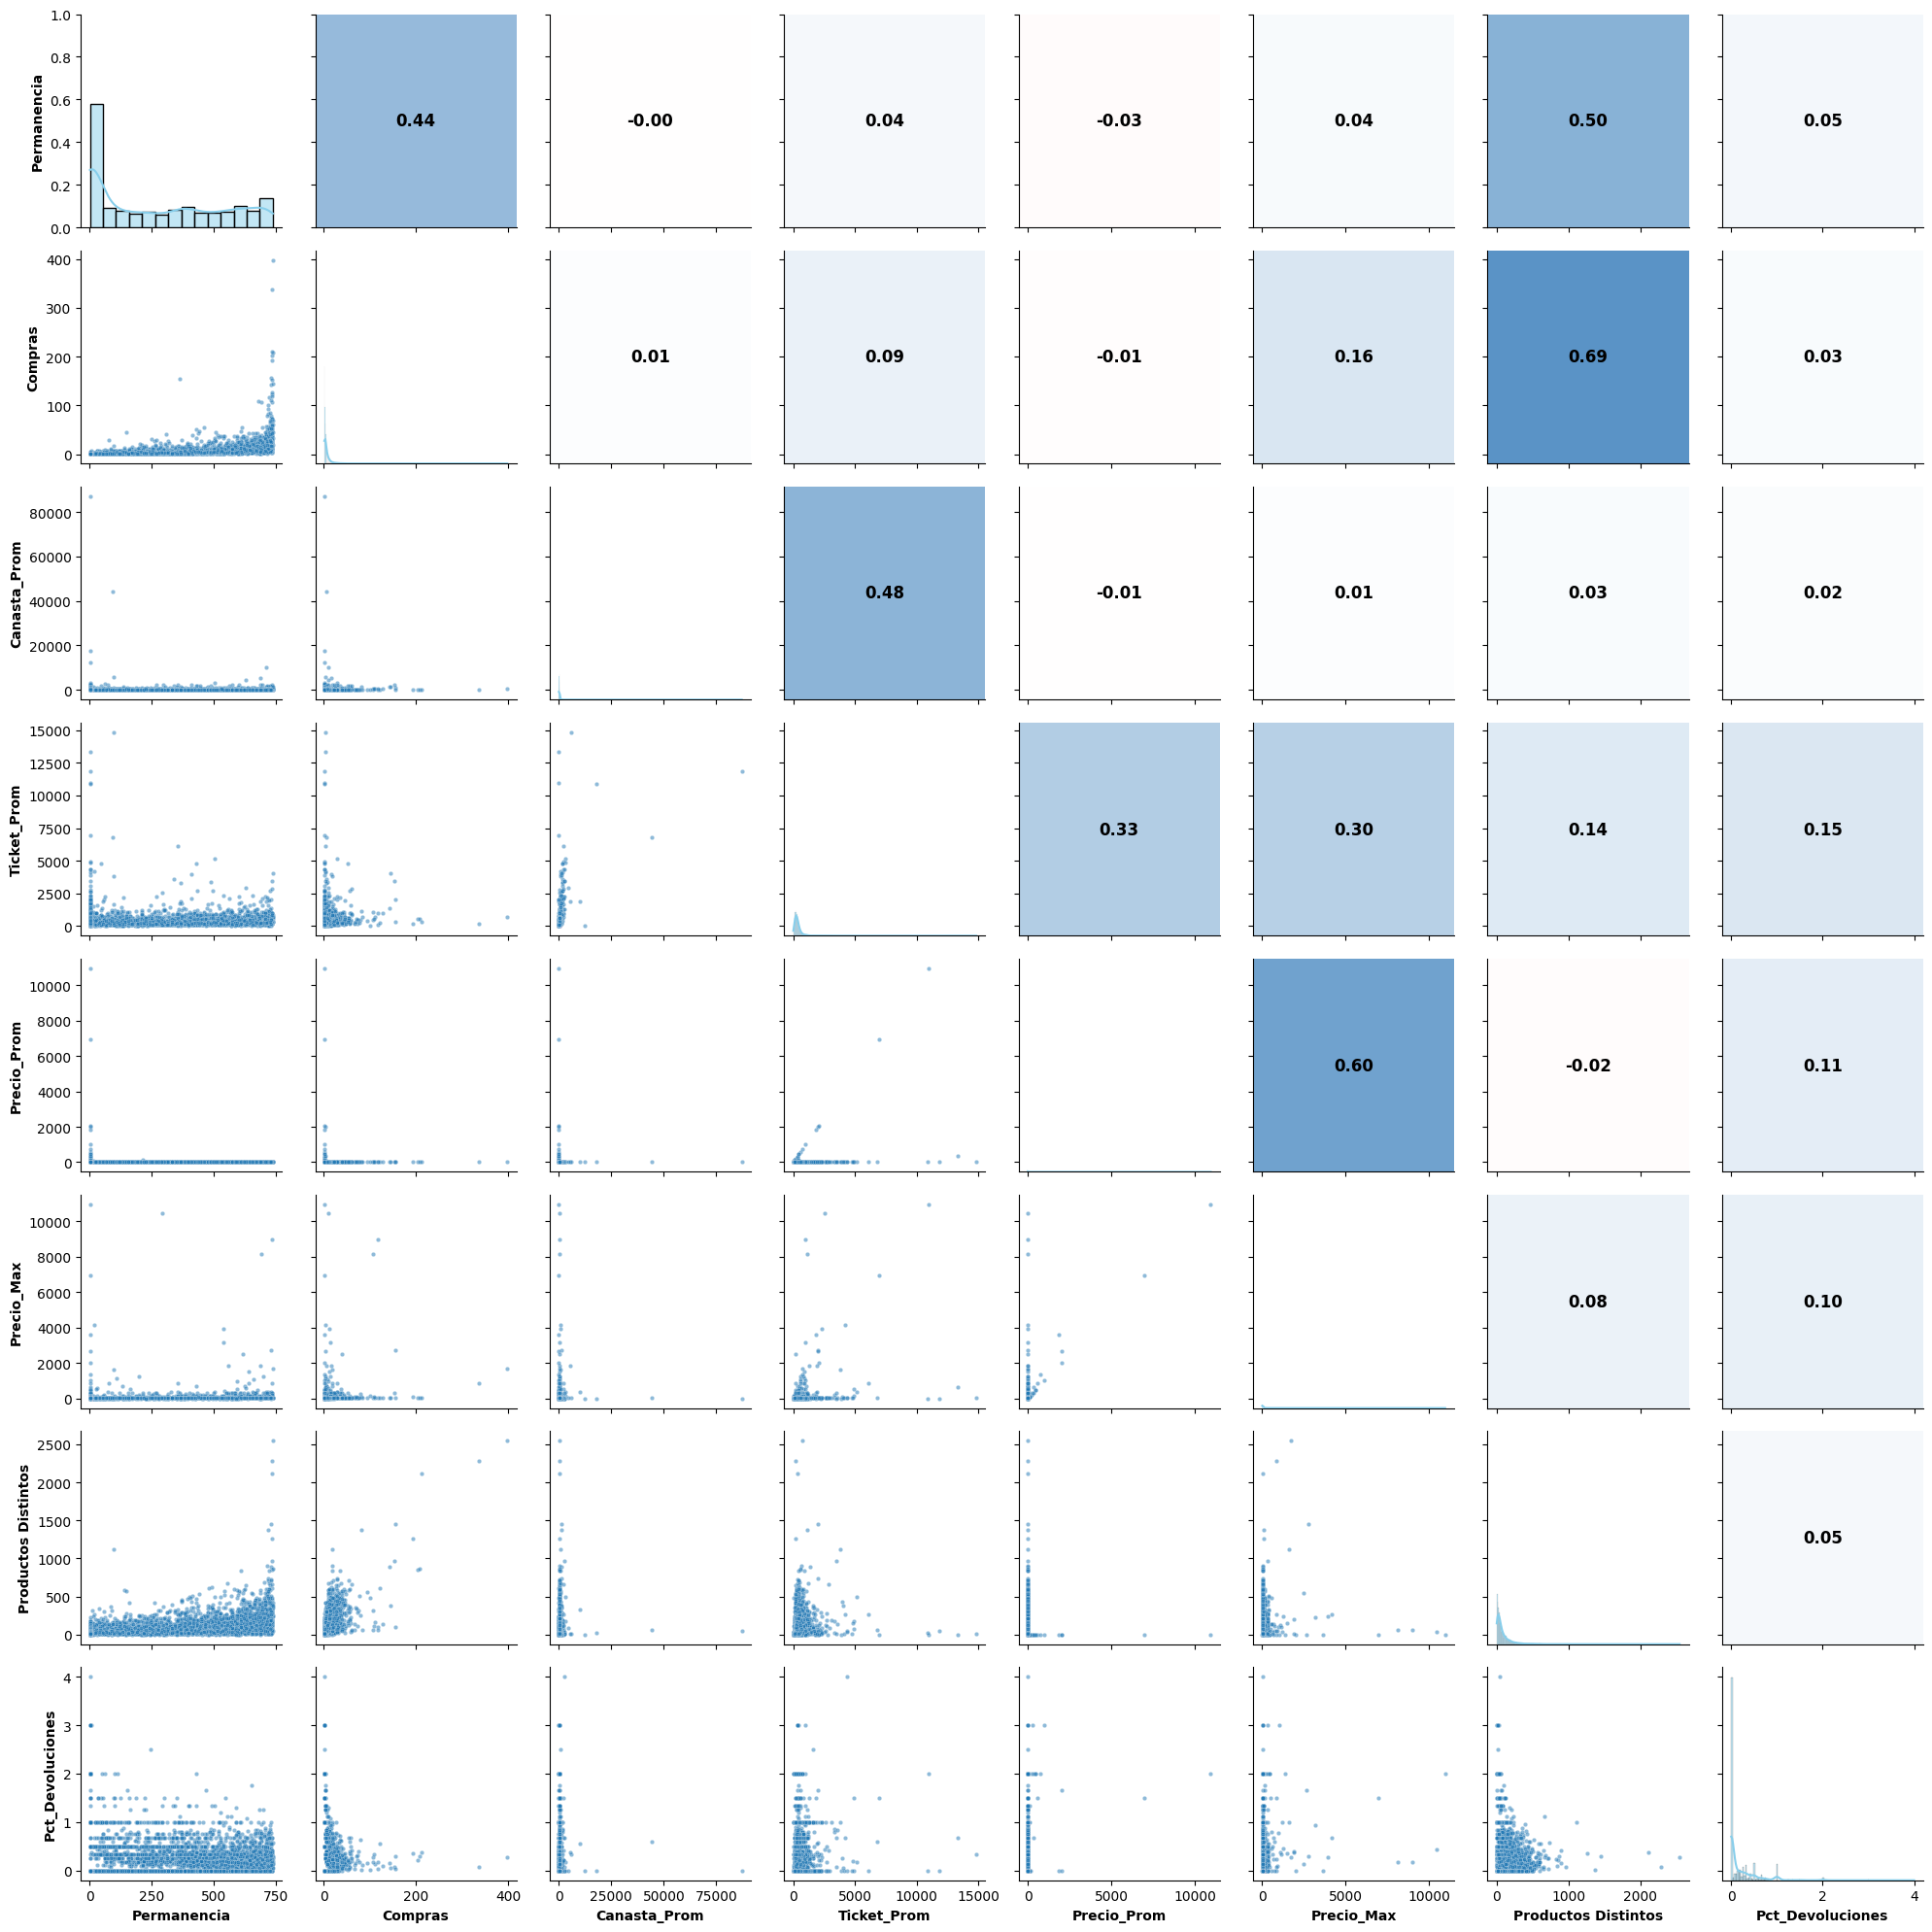

In [11]:
# Grafica correlacion de pearson y de dispersion en triangulo superior

# variables numericas
df_num = df_customer[[
    "Permanencia",
    "Compras", 
    "Canasta_Prom", "Ticket_Prom", "Precio_Prom", "Precio_Max",
    "Productos Distintos",
    "Pct_Devoluciones"
]]

cmap_corr = mcolors.LinearSegmentedColormap.from_list(
    'custom_corr', ['#ef796d', '#ffffff', '#1164ad']
)

# funcion para anotar la correlacion de pearson en el triangulo superior
def corrfunc(x, y, **kws):
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()

    color_norm = (r + 1) / 2
    ax.set_facecolor(cmap_corr(color_norm))

    ax.annotate(
        f'{r:.2f}',
        xy=(0.5, 0.5),
        xycoords=ax.transAxes,
        ha='center',
        va='center',
        fontsize=12,
        weight='bold',
    )


g = sns.PairGrid(df_num)

# scatter plot en triangulo inferior
g.map_lower(sns.scatterplot, alpha=0.5, s=10)

# histograma/KDE en diagonal
g.map_diag(sns.histplot, kde=True, color='skyblue')

# correlacion en triangulo superior
g.map_upper(corrfunc)

for ax in g.axes.flat:
  if ax is not None:
    xlabel = ax.get_xlabel()
    ylabel = ax.get_ylabel()
    if xlabel:
      ax.set_xlabel(xlabel, fontweight='bold')
    if ylabel:
      ax.set_ylabel(ylabel, fontweight='bold')

plt.tight_layout()
plt.show()

Aplicamos transformacion log normal dado que los histogramas no parecen normales y afectaria los resultados del modelos de densidad

In [12]:
df_customer_transformed = df_customer.copy()
transformers = dict()

cols_log_normal = [
    "Compras", 
    "Canasta_Prom", "Ticket_Prom", "Precio_Prom", "Precio_Max",
    "Productos Distintos"
]
for col in cols_log_normal:    
    transformer = FunctionTransformer(func=np.log1p, inverse_func=np.expm1, validate=True)
    transformer.fit(df_customer_transformed[[col]].to_numpy())
    
    transformers[col] = transformer

cols_pw_normal = [
    "Pct_Devoluciones"
]
for col in cols_pw_normal:    
    transformer = PowerTransformer(method='yeo-johnson', standardize=False)
    transformer.fit(df_customer_transformed[[col]].to_numpy())
    
    transformers[col] = transformer


for col in [*cols_log_normal, *cols_pw_normal]:
    df_customer_transformed[col] = transformers[col].transform(df_customer_transformed[[col]].to_numpy())

df_customer_transformed.describe()

,Paises Distintos,Permanencia,Compras,Canasta_Prom,Ticket_Prom,Precio_Prom,Precio_Max,Productos Distintos,Pct_Devoluciones
count,5876.000000,5876.000000,5876.000000,5876.000000,5876.000000,5876.000000,5876.000000,5876.000000,5876.000000
mean,1.002212,274.287270,1.549355,4.999872,5.621071,1.090667,2.686656,3.760129,0.065266
std,0.046988,258.997643,0.809555,0.921822,0.732573,0.465508,0.883648,1.219075,0.081191
min,1.000000,1.000000,0.693147,0.693147,0.000000,0.000000,0.000000,0.693147,-0.000000
25%,1.000000,1.000000,0.693147,4.530256,5.189364,0.887146,2.251292,2.995732,-0.000000
50%,1.000000,221.500000,1.386294,5.049856,5.641640,1.040241,2.621039,3.828641,-0.000000
75%,1.000000,513.000000,2.079442,5.556828,6.032868,1.208729,2.887590,4.644391,0.147073
max,2.000000,739.000000,5.988961,11.375593,9.605470,9.301506,9.301506,7.844241,0.217507


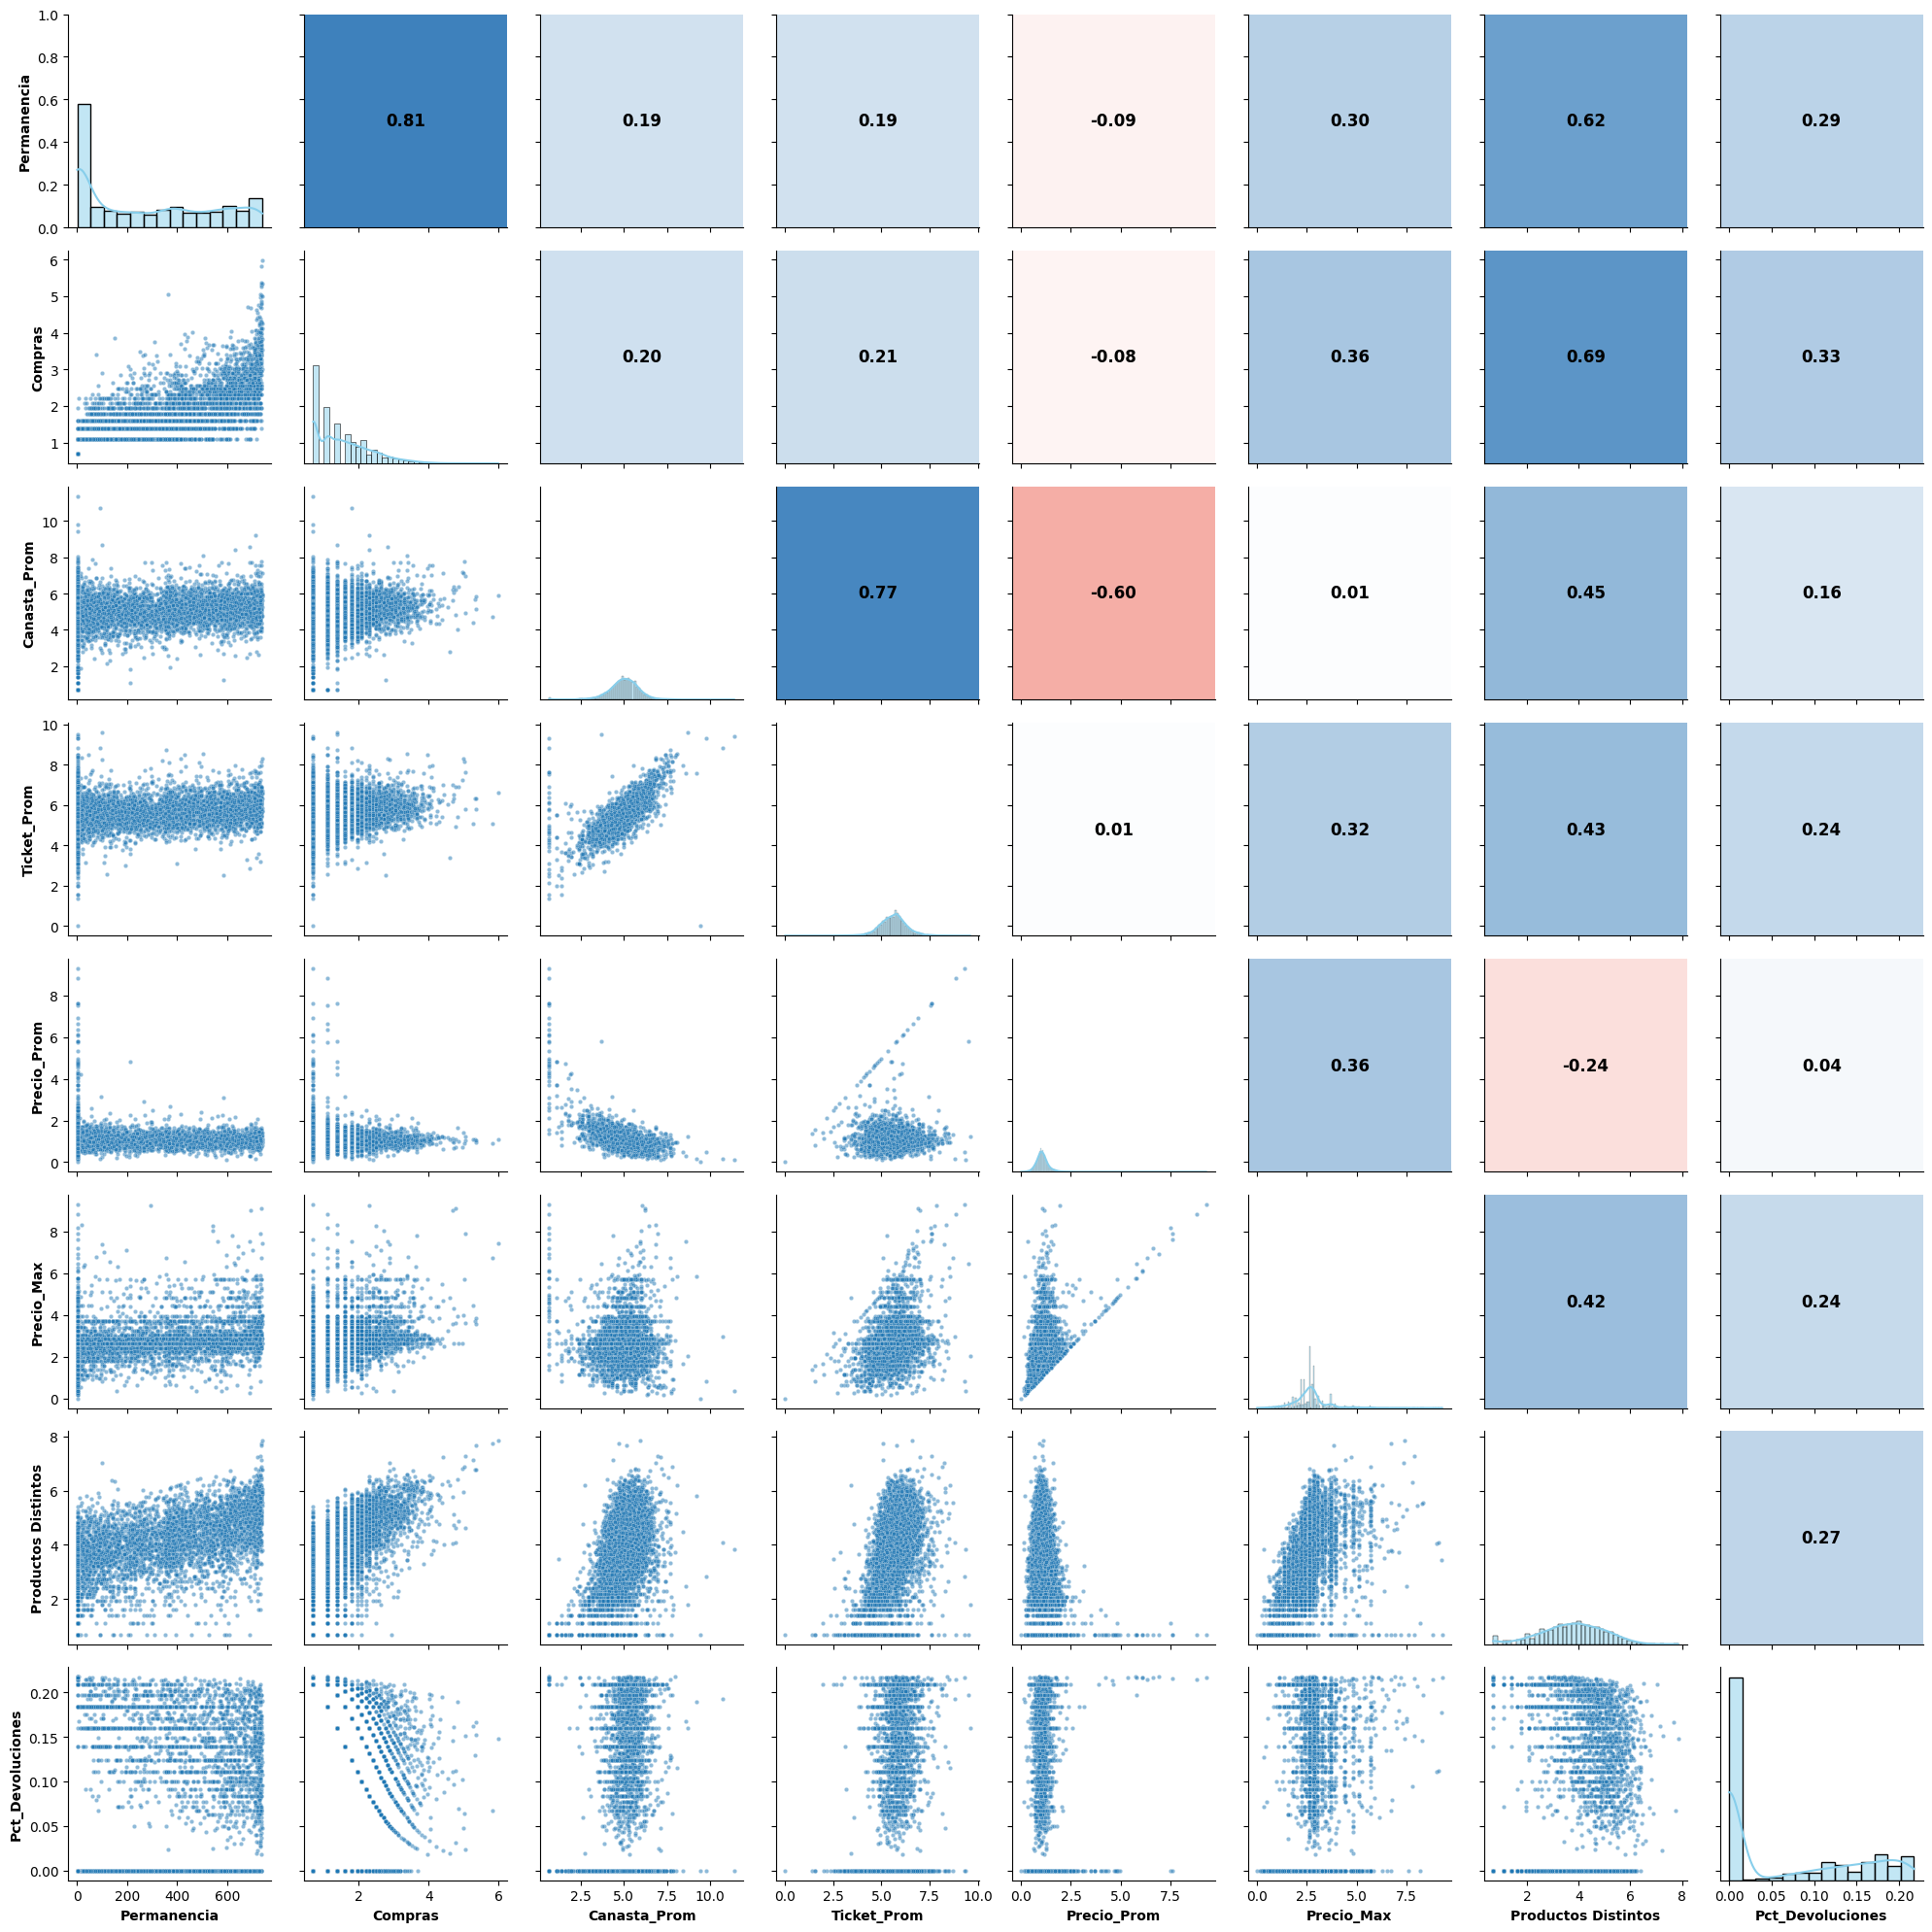

In [13]:
# Grafica correlacion de pearson y de dispersion en triangulo superior

# variables numericas
df_num = df_customer_transformed[[
    "Permanencia",
    "Compras", 
    "Canasta_Prom", "Ticket_Prom", "Precio_Prom", "Precio_Max",
    "Productos Distintos",
    "Pct_Devoluciones"
]]

cmap_corr = mcolors.LinearSegmentedColormap.from_list(
    'custom_corr', ['#ef796d', '#ffffff', '#1164ad']
)

# funcion para anotar la correlacion de pearson en el triangulo superior
def corrfunc(x, y, **kws):
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()

    color_norm = (r + 1) / 2
    ax.set_facecolor(cmap_corr(color_norm))

    ax.annotate(
        f'{r:.2f}',
        xy=(0.5, 0.5),
        xycoords=ax.transAxes,
        ha='center',
        va='center',
        fontsize=12,
        weight='bold',
    )


g = sns.PairGrid(df_num)

# scatter plot en triangulo inferior
g.map_lower(sns.scatterplot, alpha=0.5, s=10)

# histograma/KDE en diagonal
g.map_diag(sns.histplot, kde=True, color='skyblue')

# correlacion en triangulo superior
g.map_upper(corrfunc)

for ax in g.axes.flat:
  if ax is not None:
    xlabel = ax.get_xlabel()
    ylabel = ax.get_ylabel()
    if xlabel:
      ax.set_xlabel(xlabel, fontweight='bold')
    if ylabel:
      ax.set_ylabel(ylabel, fontweight='bold')

plt.tight_layout()
plt.show()

**Comentarios:**

* **Correlaciones**
    * Compras X Permanencia : Relacion positiva alta de +0.81. A mayor cantidad de tiempo como cliente, mayor la cantidad de compras que se realizan.
    * Compras X Productos Distintos: Relacion positiva alta de +0.69. A mayor cantidad de compras, mayor variedad de productos comprados.
    * Canasta promedio X Ticket promedio : Relacion positiva alta de +0.77. A mayor cantidad de unidades compradas, mayor el valor promedio de compra.
    * Canasta promedio X Precio promedio : Relacion negativa alta de -0.60. A menor precio, mayor cantidad de unidades compradas.

* **Distribuciones**
    * Tras la transofrmacion, canasta promedio, ticket promedio, precio promedio y productos distintos son aparenetemnete normales

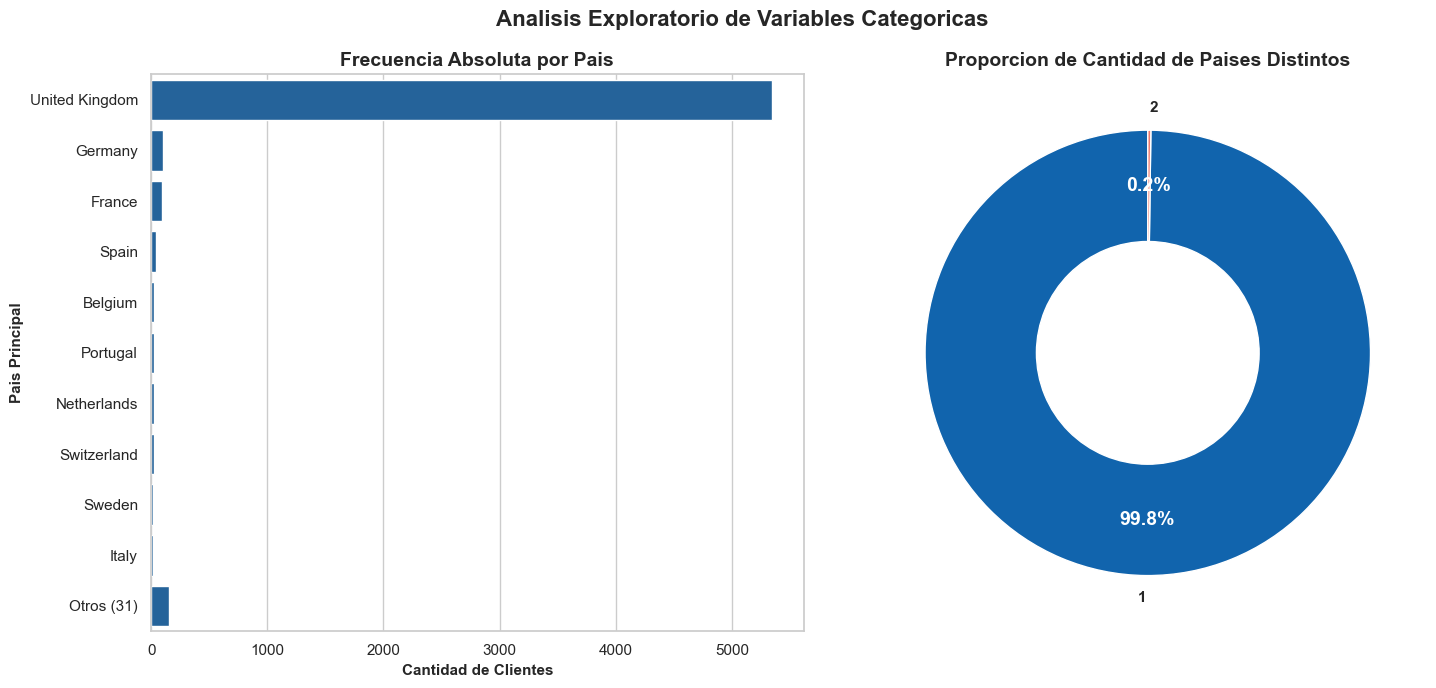

In [14]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

fig.suptitle(
    'Analisis Exploratorio de Variables Categoricas',
    fontsize=16,
    fontweight='bold',
    y=0.98,  # Ajusta la posición vertical (cerca de 1.0 queda arriba del todo)
)

cat_counts = df_customer_transformed['Pais Principal'].value_counts().sort_values(ascending=False)
cat_counts = pd.concat([
    cat_counts.iloc[:10],
    pd.Series([cat_counts.iloc[10:].sum()],name="count", index=[f"Otros ({cat_counts.iloc[10:].shape[0] :0,.0f})"])
])

sns.barplot(
    x=cat_counts.values,
    y=cat_counts.index,
    ax=axes[0],
    order=cat_counts.index,
    color="#1164ad",
    # palette='Blues_r',
    # hue=cat_counts.index,
    # hue_order=cat_counts.index,
    legend=False,
    width=0.8,
)
axes[0].set_title(
    'Frecuencia Absoluta por Pais', fontweight='bold', fontsize=14
)
axes[0].set_xlabel('Cantidad de Clientes', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Pais Principal', fontweight='bold', fontsize=11)



market_counts = df_customer_transformed["Paises Distintos"].value_counts()
labels = ['1', '2']
colors = ['#1164ad', '#ef796d']

# pctdistance fuera del círculo (ej. 1.2 o 1.25)
wedges, texts, autotexts = axes[1].pie(
    market_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.5, edgecolor='w'),
    pctdistance=.75,
)

# Estilar textos y porcentajes fuera
for text in texts:
  text.set_fontsize(11)
  text.set_weight('bold')

for autotext in autotexts:
  autotext.set_fontsize(14)
  autotext.set_weight('bold')
  autotext.set_color('#ffffff')

axes[1].set_title(
    'Proporcion de Cantidad de Paises Distintos', fontweight='bold', fontsize=14
)



plt.tight_layout()
plt.show()
sns.reset_defaults()

**Comentarios:**

* **Pais principal :** El 91% de los clientes hicieron la mayoria de sus compras en UK. El resto se distribuye en los otro 40 paises diferentes.
* **Paises Distintos :** El 99.8% de los clientes hicieron todas sus compras en un solo pais. Y el restante, lo hizo en 2.

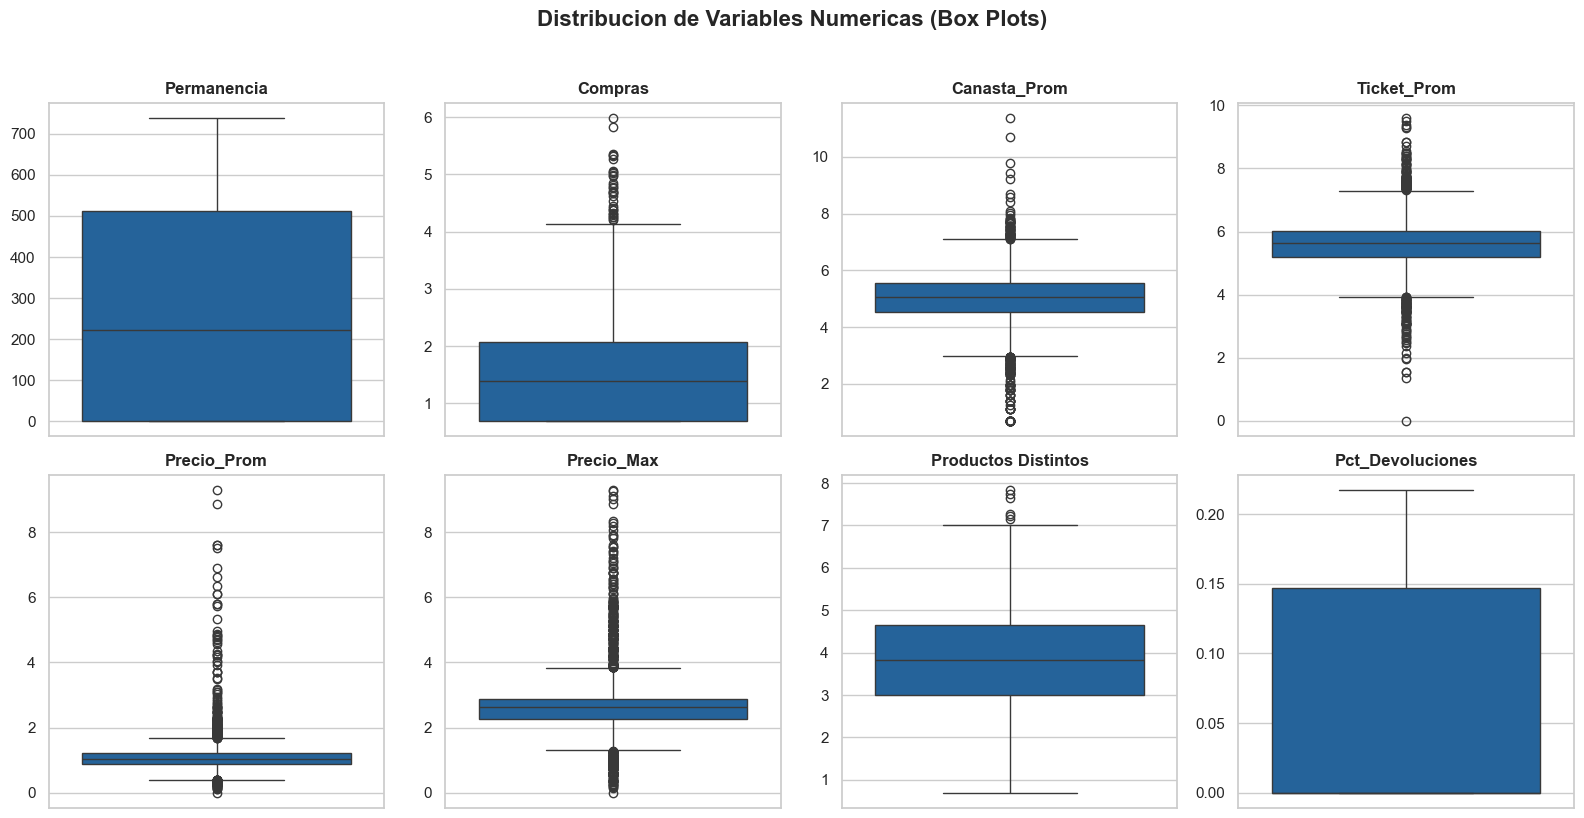

In [15]:
cols_boxplot = [
    "Permanencia",
    "Compras",
    "Canasta_Prom", "Ticket_Prom", "Precio_Prom", "Precio_Max",
    "Productos Distintos",
    "Pct_Devoluciones"
]
 
n_cols = 4
n_rows = int(np.ceil(len(cols_boxplot) / n_cols))
 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()
 
fig.suptitle(
    "Distribucion de Variables Numericas (Box Plots)",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
 
for ax, col in zip(axes, cols_boxplot):
    sns.boxplot(y=df_customer_transformed[col], ax=ax, color="#1164ad")
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("")
 
for ax in axes[len(cols_boxplot):]:
    ax.axis("off")
 
plt.tight_layout()
plt.show()
sns.reset_defaults()

**Comentarios**

* **Permanencia**: Como mencionamos anteriormente, la mayoría de los usuarios permanecen siendo clientes por un periodo de tiempo entre 0 y 500 días, teniendo un máximo (no outlier) de poco más de 700 días (casi 2 años)
* **Compras**: Claramente podemos ver outliers positivos, es decir, hay clientes que tienden a realizar más compras de lo común. 
* **Canasta promedio**: Por otro lado, tenemos outliers tanto positivos como negativos, indicando que de igual forma hay clientes que tienden a comprar más o menos productos que la mayoría. 
* **Ticket promedio**: Es muy similar a canasta promedio, de igual manera se muestran clientes teniendo compras con valor más alto y/o más bajo que el 50% de los usuarios, los cuales están dentro de un rango de $5 y $6 por persona.
* **Precio promedio y Precio Max**: Estas dos variables están relacionadas, ya que el precio promedio se puede ver afectado por el precio máximo. Dicho esto, pareciera que existen varios artículos de precio considerablemente más alto. 

# Preprocesamiento

In [52]:
df_customer_transformed["Comprador Local"] = (df_customer_transformed["Pais Principal"]=='United Kingdom').astype(int)
df_customer_transformed["Nomada"] = (df_customer_transformed["Paises Distintos"]>1).astype(int)

df_customer_transformed

,Pais Principal,Paises Distintos,Permanencia,Compras,Canasta_Prom,Ticket_Prom,Precio_Prom,Precio_Max,Productos Distintos,Pct_Devoluciones,Comprador Local,Nomada,anomalia_dbscan
CustomerID,,,,,,,,,,,,,
12347.0,Iceland,1,403.0,2.197225,5.918558,6.423557,0.977858,2.621039,4.844187,-0.000000,0,0,1
12348.0,Finland,1,364.0,1.791759,6.298582,6.003591,0.556220,3.713572,3.258097,-0.000000,0,0,1
12349.0,Italy,1,572.0,1.609438,6.008813,7.010468,1.315611,5.707110,4.934474,0.139574,0,0,1
12350.0,Norway,1,1.0,0.693147,5.288267,5.815324,0.992311,3.713572,2.890372,-0.000000,0,0,1
12351.0,Unspecified,1,1.0,0.693147,5.568345,5.710195,0.766857,2.621039,3.091042,-0.000000,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18283.0,United Kingdom,1,656.0,3.135494,4.379182,4.831454,0.947456,2.830268,5.866468,-0.000000,1,0,1
18284.0,United Kingdom,1,1.0,0.693147,6.204558,6.137036,0.659888,3.931826,3.367296,0.208634,1,0,1
18285.0,United Kingdom,1,1.0,0.693147,4.983607,6.059123,1.372405,3.931826,2.564949,-0.000000,1,0,0


In [53]:
# Definimos las columnas numéricas continuas
columnas_numericas = ['Permanencia', 'Compras', 'Canasta_Prom', 'Ticket_Prom',
                       'Precio_Prom', 'Precio_Max', 'Productos Distintos',
                       'Pct_Devoluciones']
 
# Escalamos solo las numéricas continuas
scaler = StandardScaler()
df_num_escalado = pd.DataFrame(
    scaler.fit_transform(df_customer_transformed[columnas_numericas]),
    columns=columnas_numericas,
    index=df_customer_transformed.index
)

df_cat_escalado = df_customer_transformed[["Comprador Local","Nomada"]]#*4

# Dataset final para los modelos
df_final = pd.concat([df_num_escalado, df_cat_escalado], axis=1)
 
print(df_final.shape)

df_final.head()

(5876, 10)


,Permanencia,Compras,Canasta_Prom,Ticket_Prom,Precio_Prom,Precio_Max,Productos Distintos,Pct_Devoluciones,Comprador Local,Nomada
CustomerID,,,,,,,,,,
12347.0,0.497007,0.800347,0.996682,1.095527,-0.242354,-0.074263,0.889322,-0.803925,0,0
12348.0,0.346414,0.299455,1.408970,0.522203,-1.148191,1.162232,-0.411849,-0.803925,0,0
12349.0,1.149578,0.074223,1.094601,1.896758,0.483263,3.418458,0.963390,0.915303,0,0
12350.0,-1.055263,-1.057718,0.312880,0.265187,-0.211304,1.162232,-0.713517,-0.803925,0,0
12351.0,-1.055263,-1.057718,0.616736,0.121669,-0.695665,-0.074263,-0.548894,-0.803925,0,0


In [54]:
df_resultados = df_final.copy()

# Modelo DBSCAN

## Optimización de hiperparámetros

In [55]:
def objective_dbscan(trial):
    params_dbsc = {
        'eps' : trial.suggest_float(
            'eps', low=0.1, high=3.0
        ),
       
        'min_samples' : trial.suggest_int(
            'min_samples', low=2, high=50
        )
    }
 
    model_dbsc_trial = DBSCAN(
        **params_dbsc
    )
   
    labels_trial = model_dbsc_trial.fit_predict(df_final)

    n_clusters = len(set(labels_trial)) - (1 if -1 in labels_trial else 0)

    # Si no hay al menos 2 clusters reales (sin contar ruido), no se puede calcular silhouette
    if n_clusters < 2:
        return -1  # peor score posible, para que Optuna descarte esta combinación

    score_trial = silhouette_score(df_final, labels_trial)

    return score_trial

In [34]:
sampler = samplers.TPESampler(seed=42)
study_dbsc = create_study(direction='maximize', study_name='DBSC_study', sampler=sampler)
 
optuna_logging.set_verbosity(optuna_logging.WARNING)
study_dbsc.optimize(objective_dbscan, n_trials=20)
optuna_logging.set_verbosity(optuna_logging.INFO)

[I 2026-08-08 18:36:11,275] A new study created in memory with name: DBSC_study


In [38]:
resultados = study_dbsc.trials_dataframe()
resultados.sort_values(by="value", ascending=False, inplace=True)
resultados.drop_duplicates(subset=["value",*[col for col in resultados.columns if col.startswith('params')]], inplace=True)
resultados["value_increase"] = resultados["value"] - resultados["value"].shift(-1)
resultados[["value","value_increase"]] = resultados[["value","value_increase"]].round(4)
resultados.head(10)

,number,value,datetime_start,datetime_complete,duration,params_eps,params_min_samples,state,value_increase
14,14,0.0805,2026-08-08 18:36:53.006057,2026-08-08 18:36:56.525021,0 days 00:00:03.518964,0.882829,29,COMPLETE,0.0091
12,12,0.0714,2026-08-08 18:36:48.347040,2026-08-08 18:36:50.887111,0 days 00:00:02.540071,0.831241,22,COMPLETE,0.0444
19,19,0.0270,2026-08-08 18:37:01.840306,2026-08-08 18:37:05.397168,0 days 00:00:03.556862,0.852022,41,COMPLETE,0.0946
8,8,-0.0675,2026-08-08 18:36:30.271279,2026-08-08 18:36:34.202680,0 days 00:00:03.931401,0.982303,27,COMPLETE,0.0706
15,15,-0.1381,2026-08-08 18:36:56.525021,2026-08-08 18:36:58.759078,0 days 00:00:02.234057,0.783183,36,COMPLETE,0.0665
7,7,-0.2046,2026-08-08 18:36:27.354916,2026-08-08 18:36:30.271279,0 days 00:00:02.916363,0.627292,10,COMPLETE,0.1160
11,11,-0.3206,2026-08-08 18:36:42.218334,2026-08-08 18:36:48.347040,0 days 00:00:06.128706,0.948534,3,COMPLETE,0.0828
2,2,-0.4033,2026-08-08 18:36:15.958195,2026-08-08 18:36:18.739342,0 days 00:00:02.781147,0.552454,9,COMPLETE,0.5967
18,18,-1.0000,2026-08-08 18:37:00.603433,2026-08-08 18:37:01.840306,0 days 00:00:01.236873,1.183374,30,COMPLETE,0.0000
17,17,-1.0000,2026-08-08 18:37:00.217170,2026-08-08 18:37:00.603433,0 days 00:00:00.386263,0.444198,36,COMPLETE,0.0000


In [37]:
print(study_dbsc.best_params)
print(study_dbsc.best_value)

{'eps': 0.8828294213829455, 'min_samples': 29}
0.08053290539470856


## Modelo

In [56]:
# eps y min_samples son los hiperparámetros clave, ya optimizados
dbscan = DBSCAN(**study_dbsc.best_params)
labels_dbscan = dbscan.fit_predict(df_final)  # df_final SIN modificar

# Silhouette calculado sobre el df_final limpio (antes de agregar nada)
n_clusters_final = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
if n_clusters_final >= 2:
    sil_score = silhouette_score(df_resultados, labels_dbscan)
    print("Silhouette Score:", sil_score)

df_resultados['anomalia_dbscan'] = np.where(labels_dbscan == -1, 1, 0)

print("Anomalías detectadas por DBSCAN:", df_resultados['anomalia_dbscan'].sum())
print("Porcentaje:", df_resultados['anomalia_dbscan'].mean() * 100, "%")

Silhouette Score: 0.08053290539470856
Anomalías detectadas por DBSCAN: 2295
Porcentaje: 39.0571817562968 %


In [57]:
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(df_final)

df_plot = pd.DataFrame(componentes, columns=['PC1', 'PC2'], index=df_final.index)
df_plot['cluster'] = labels_dbscan  # -1 = anomalía/ruido

print("Varianza explicada por las 2 componentes:", pca.explained_variance_ratio_.sum())

Varianza explicada por las 2 componentes: 0.6214991902316269


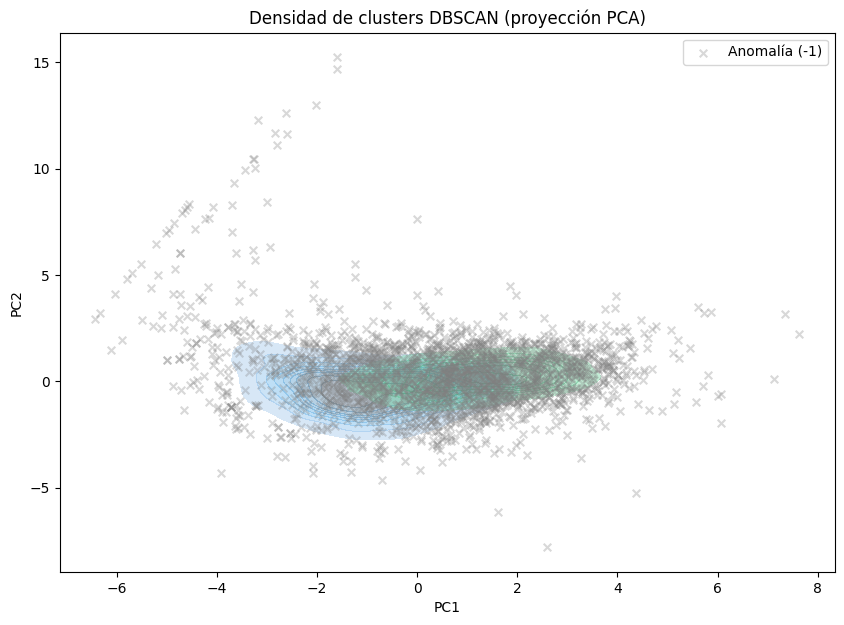

In [58]:
plt.figure(figsize=(10, 7))

# Puntos normales coloreados por cluster
sns.kdeplot(
    data=df_plot[df_plot['cluster'] != -1],
    x='PC1', y='PC2',
    hue='cluster',
    fill=True,
    alpha=0.4,
    palette='viridis'
)

# Las anomalías (-1) se marcan encima como puntos individuales, no como densidad
anomalias = df_plot[df_plot['cluster'] == -1]
plt.scatter(anomalias['PC1'], anomalias['PC2'], color='gray', label='Anomalía (-1)', s=30, marker='x', alpha=0.3)

plt.title('Densidad de clusters DBSCAN (proyección PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

In [59]:
# Creamos una columna de cluster con formato legible ("Ruido (-1)" en vez de -1)
df_resultados['cluster_label'] = np.where(
    labels_dbscan == -1,
    'Ruido (-1)',
    'Cluster ' + pd.Series(labels_dbscan, index=df_resultados.index).astype(str)
)

col_cluster = 'cluster_label'

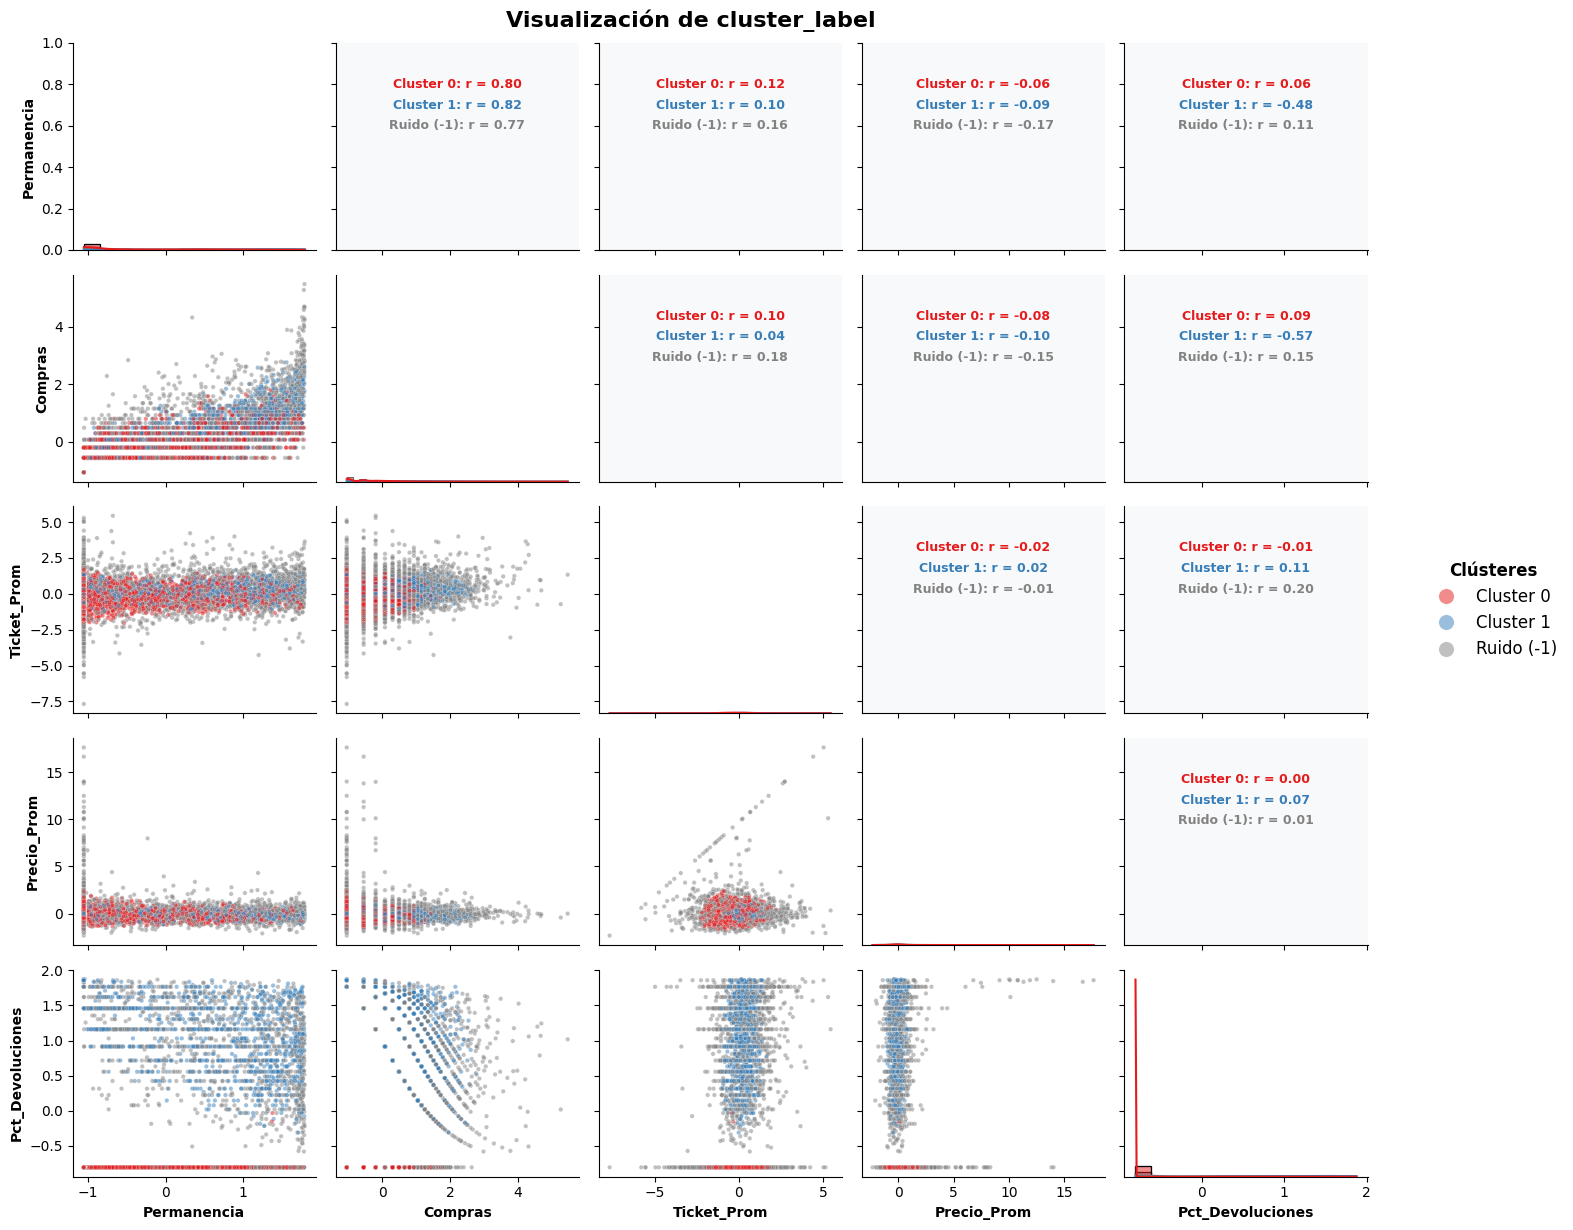

In [60]:
# Variables numéricas de tu dataset
cols_numericas = [
    'Permanencia',
    'Compras',
    'Ticket_Prom',
    'Precio_Prom',
    'Pct_Devoluciones',
]

df_num = df_resultados[[*cols_numericas, col_cluster]].copy()
df_num[col_cluster] = df_num[col_cluster].astype(str)

cmap_corr = mcolors.LinearSegmentedColormap.from_list(
    'custom_corr', ['#ef796d', '#ffffff', '#1164ad']
)

# Ordenamos los clusters, dejando "Ruido (-1)" fuera del orden natural
clusters_unicos = sorted(df_num[col_cluster].unique())
palette = {}
if 'Ruido (-1)' in clusters_unicos:
    palette['Ruido (-1)'] = "#828282"
    clusters_unicos.remove('Ruido (-1)')

palette_restante = sns.color_palette('Set1', len(clusters_unicos))
for c, color in zip(clusters_unicos, palette_restante):
    palette[c] = color


def corrfunc_por_cluster_individual(x, y, **kws):
    ax = plt.gca()
    ax.set_facecolor('#f8f9fa')

    for t in list(ax.texts):
        t.remove()

    x_name = x.name
    y_name = y.name

    clusters = sorted(df_resultados[col_cluster].astype(str).unique())

    y_pos = 0.8
    spacing = 0.1

    for c in clusters:
        subset = df_resultados[df_resultados[col_cluster].astype(str) == c]
        vx = subset[x_name].dropna()
        vy = subset[y_name].dropna()

        if len(vx) > 1 and len(vy) > 1:
            r_sub = np.corrcoef(vx, vy)[0, 1]
            texto = f'{c}: r = {r_sub:.2f}'
        else:
            texto = f'{c}: N/A'

        color_cluster = palette.get(c, 'black')

        ax.annotate(
            texto,
            xy=(0.5, y_pos),
            xycoords=ax.transAxes,
            ha='center',
            va='center',
            fontsize=9,
            weight='bold',
            color=color_cluster,
        )

        y_pos -= spacing


g = sns.PairGrid(df_num, hue=col_cluster, palette=palette, hue_order=sorted(df_num[col_cluster].unique()))

g.fig.suptitle(
    f'Visualización de {col_cluster}',
    fontsize=16,
    fontweight='bold',
    y=0.98,
)

g.map_lower(sns.scatterplot, alpha=0.5, s=10)
g.map_diag(sns.histplot, kde=True, color='skyblue')
g.map_upper(corrfunc_por_cluster_individual)

g.add_legend(title='Clústeres', bbox_to_anchor=(1.02, 0.5), loc='center left', fontsize=12)
g._legend.get_title().set_fontweight('bold')
g._legend.get_title().set_fontsize(12)
handles = (
    g._legend.legend_handles
    if hasattr(g._legend, 'legend_handles')
    else g._legend.legendHandles
)
for lh in handles:
    if hasattr(lh, 'set_sizes'):
        lh.set_sizes([150])
    elif hasattr(lh, 'set_markersize'):
        lh.set_markersize(11)

for ax in g.axes.flat:
    if ax is not None:
        xlabel = ax.get_xlabel()
        ylabel = ax.get_ylabel()
        if xlabel:
            ax.set_xlabel(xlabel, fontweight='bold')
        if ylabel:
            ax.set_ylabel(ylabel, fontweight='bold')

plt.tight_layout()
plt.show()

## Evaluación DBSCAN

In [26]:
# Perfil promedio de las variables (escaladas) segun si el cliente fue marcado como anomalia
cols_perfil = [
    'Permanencia', 'Compras', 'Canasta_Prom', 'Ticket_Prom',
    'Precio_Prom', 'Precio_Max', 'Productos Distintos', 'Pct_Devoluciones'
]

perfil_dbscan = df_resultados.groupby('anomalia_dbscan')[cols_perfil].mean().round(2)
perfil_dbscan.index = ['Normal (0)', 'Anomalia (1)']
perfil_dbscan


,Permanencia,Compras,Canasta_Prom,Ticket_Prom,Precio_Prom,Precio_Max,Productos Distintos,Pct_Devoluciones
Normal (0),-0.13,-0.20,-0.01,-0.09,-0.12,-0.22,0.01,-0.19
Anomalia (1),0.21,0.31,0.02,0.14,0.18,0.34,-0.02,0.30


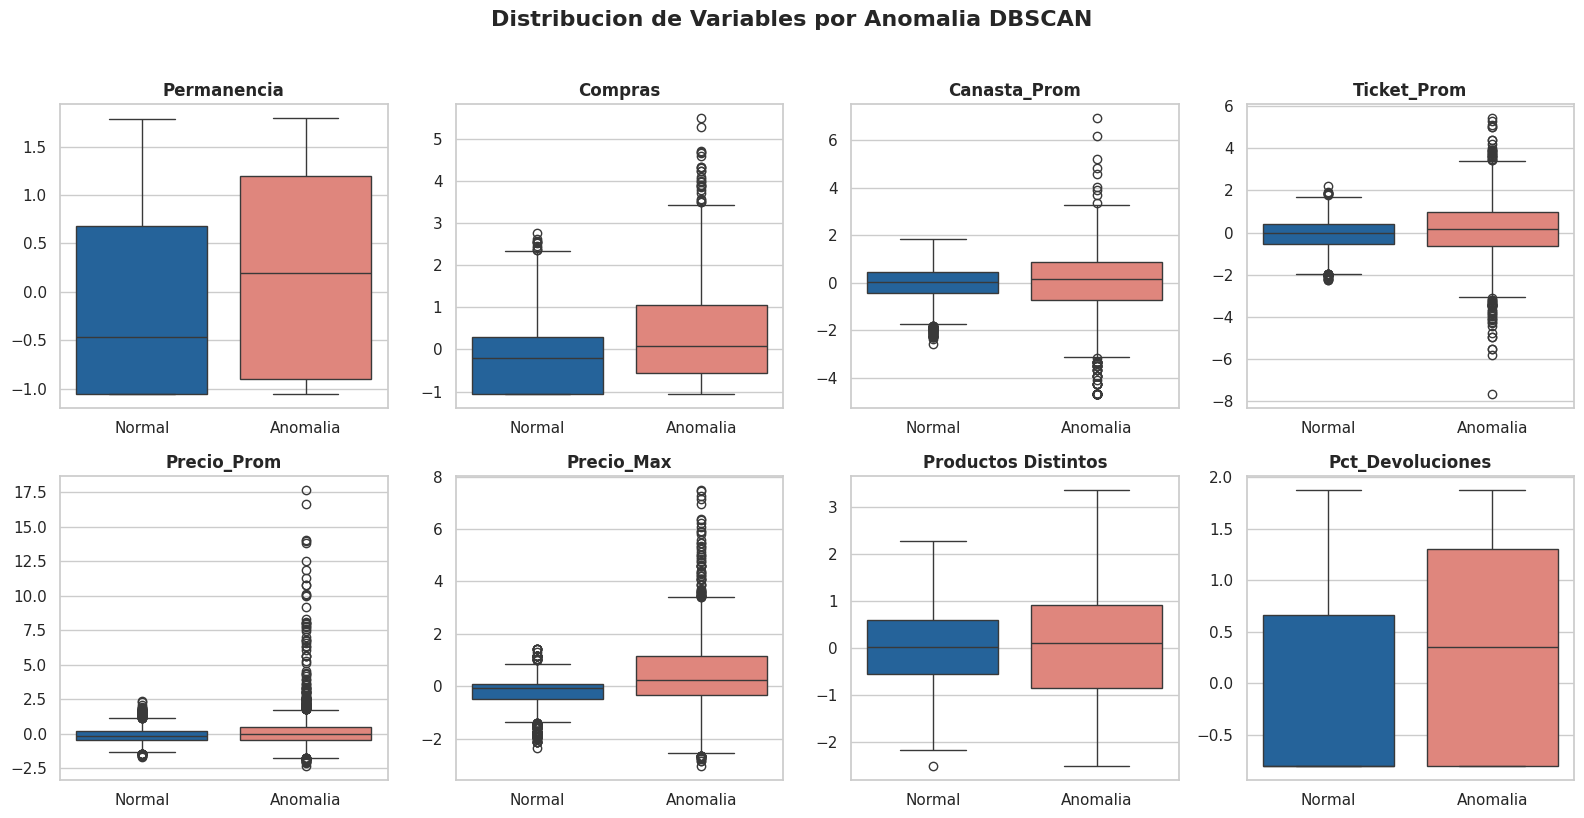

In [27]:
# Boxplots comparando la distribucion de cada variable entre clientes normales y anomalias
n_cols = 4
n_rows = int(np.ceil(len(cols_perfil) / n_cols))

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()

fig.suptitle(
    'Distribucion de Variables por Anomalia DBSCAN',
    fontsize=16,
    fontweight='bold',
    y=1.02,
)

for ax, col in zip(axes, cols_perfil):
    sns.boxplot(data=df_resultados, x='anomalia_dbscan', y=col, ax=ax, hue='anomalia_dbscan', palette={0: '#1164ad', 1: '#ef796d'}, legend=False)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Normal', 'Anomalia'])

for ax in axes[len(cols_perfil):]:
    ax.axis('off')

plt.tight_layout()
plt.show()
sns.reset_defaults()


**Comentarios:**

* **Silhouette Score :** El score obtenido (~0.08) esta muy cerca de 0, lo cual indica que los clusters formados por DBSCAN se encuentran bastante solapados entre si. Esto es consistente con la naturaleza del dataset, donde no existen grupos de densidad claramente separados sino un continuo de comportamientos de compra.
* **Porcentaje de anomalias :** DBSCAN marco como ruido (anomalia) al 39.06% de los clientes (2,295 de 5,876). Este porcentaje es demasiado alto para considerarse un conjunto de anomalias accionable desde el punto de vista de negocio; mas bien refleja zonas de baja densidad del espacio de variables que DBSCAN no logra asignar a ninguno de los 2 clusters encontrados.
* **Perfil promedio :** Los clientes marcados como anomalia muestran valores ligeramente mas altos en Permanencia, Compras, Ticket_Prom, Precio_Max y Pct_Devoluciones, pero las diferencias respecto a los clientes normales son pequeñas (diferencias de medias menores a 0.35 desviaciones estandar). Esto refuerza que el "ruido" de DBSCAN no corresponde a un grupo de outliers extremos, sino a clientes en zonas de transicion entre clusters.
* **Conclusion :** DBSCAN logra segmentar un cluster mayoritario de clientes con comportamiento tipico, pero su definicion de anomalia (el ruido) es demasiado amplia y poco discriminativa para usarse como deteccion de anomalias por si sola, dado el bajo silhouette score y la debil separacion de perfiles.


# Modelo Isolation Forest

## Optimización de hiperparámetros

In [28]:
def objective_isoforest(trial):
    params_isof = {
        'n_estimators' : trial.suggest_int(
            'n_estimators', low=50, high=300
        ),

        'max_samples' : trial.suggest_float(
            'max_samples', low=0.1, high=1.0
        ),

        'contamination' : trial.suggest_float(
            'contamination', low=0.01, high=0.4
        ),

        'max_features' : trial.suggest_float(
            'max_features', low=0.5, high=1.0
        ),
    }

    model_isof_trial = IsolationForest(
        random_state=42,
        **params_isof
    )

    labels_trial = model_isof_trial.fit_predict(df_final)

    n_clusters = len(set(labels_trial))

    # Si todos los puntos caen en una sola clase (todos normales o todos anomalia), no se puede calcular silhouette
    if n_clusters < 2:
        return -1  # peor score posible, para que Optuna descarte esta combinación

    score_trial = silhouette_score(df_final, labels_trial)

    return score_trial


In [29]:
sampler = samplers.TPESampler(seed=42)
study_isof = create_study(direction='maximize', study_name='ISOF_study', sampler=sampler)

optuna_logging.set_verbosity(optuna_logging.WARNING)
study_isof.optimize(objective_isoforest, n_trials=20)
optuna_logging.set_verbosity(optuna_logging.INFO)


[I 2026-08-09 02:08:56,995] A new study created in memory with name: ISOF_study


In [30]:
resultados = study_isof.trials_dataframe()
resultados.sort_values(by="value", ascending=False, inplace=True)
resultados.drop_duplicates(subset=["value",*[col for col in resultados.columns if col.startswith('params')]], inplace=True)
resultados["value_increase"] = resultados["value"] - resultados["value"].shift(-1)
resultados[["value","value_increase"]] = resultados[["value","value_increase"]].round(4)
resultados.head(10)


,number,value,datetime_start,datetime_complete,duration,params_contamination,params_max_features,params_max_samples,params_n_estimators,state,value_increase
12,12,0.5835,2026-08-09 02:09:14.301872,2026-08-09 02:09:16.119439,0 days 00:00:01.817567,0.013322,0.984047,0.573933,236,COMPLETE,0.0070
11,11,0.5764,2026-08-09 02:09:13.140180,2026-08-09 02:09:14.301806,0 days 00:00:01.161626,0.013751,0.990321,0.457625,54,COMPLETE,0.0056
19,19,0.5709,2026-08-09 02:09:25.695079,2026-08-09 02:09:27.511622,0 days 00:00:01.816543,0.015420,0.939807,0.658833,222,COMPLETE,0.0044
13,13,0.5665,2026-08-09 02:09:16.119519,2026-08-09 02:09:17.913762,0 days 00:00:01.794243,0.016506,0.874856,0.448173,250,COMPLETE,0.0140
2,2,0.5525,2026-08-09 02:08:59.403474,2026-08-09 02:09:01.197476,0 days 00:00:01.794002,0.018028,0.984955,0.737265,200,COMPLETE,0.0611
1,1,0.4914,2026-08-09 02:08:58.718994,2026-08-09 02:08:59.403390,0 days 00:00:00.684396,0.032653,0.933088,0.240395,89,COMPLETE,0.0812
18,18,0.4103,2026-08-09 02:09:24.049105,2026-08-09 02:09:25.695012,0 days 00:00:01.645907,0.059568,0.842752,0.492427,174,COMPLETE,0.0004
16,16,0.4098,2026-08-09 02:09:20.198842,2026-08-09 02:09:22.215734,0 days 00:00:02.016892,0.055267,0.998008,0.687703,294,COMPLETE,0.0374
3,3,0.3724,2026-08-09 02:09:01.197548,2026-08-09 02:09:02.963845,0 days 00:00:01.766297,0.080912,0.591702,0.291105,258,COMPLETE,0.0280
6,6,0.3444,2026-08-09 02:09:05.842370,2026-08-09 02:09:07.423786,0 days 00:00:01.581416,0.087873,0.757117,0.806658,164,COMPLETE,0.0062


In [31]:
print(study_isof.best_params)
print(study_isof.best_value)


{'n_estimators': 236, 'max_samples': 0.5739328498550292, 'contamination': 0.013321553045214003, 'max_features': 0.984047375706068}
0.5834507706063718


## Modelo

In [32]:
# n_estimators, max_samples, contamination y max_features son los hiperparámetros clave, ya optimizados
isoforest = IsolationForest(random_state=42, **study_isof.best_params)
labels_isof = isoforest.fit_predict(df_final)  # df_final SIN modificar, 1 = normal, -1 = anomalia

# Silhouette calculado sobre df_final (df_resultados ya trae columnas no numericas de DBSCAN)
sil_score_isof = silhouette_score(df_final, labels_isof)
print("Silhouette Score:", sil_score_isof)

df_resultados['anomalia_isof'] = np.where(labels_isof == -1, 1, 0)

print("Anomalías detectadas por Isolation Forest:", df_resultados['anomalia_isof'].sum())
print("Porcentaje:", df_resultados['anomalia_isof'].mean() * 100, "%")


Silhouette Score: 0.5834507706063718
Anomalías detectadas por Isolation Forest: 79
Porcentaje: 1.3444520081688223 %


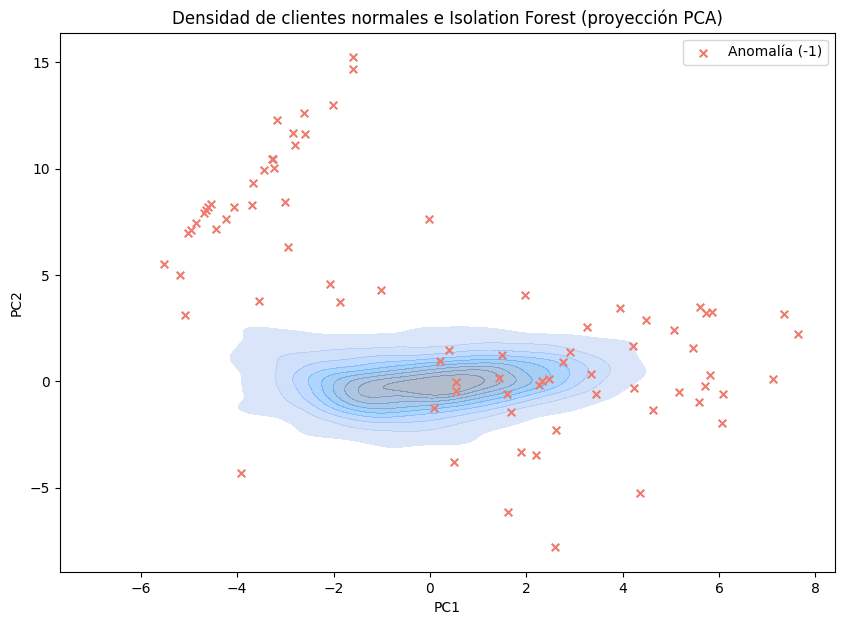

In [33]:
# Reutilizamos la proyeccion PCA calculada para DBSCAN (mismo df_final, mismas 2 componentes)
df_plot_isof = pd.DataFrame(componentes, columns=['PC1', 'PC2'], index=df_final.index)
df_plot_isof['cluster'] = labels_isof  # -1 = anomalía

plt.figure(figsize=(10, 7))

# Puntos normales como densidad
sns.kdeplot(
    data=df_plot_isof[df_plot_isof['cluster'] != -1],
    x='PC1', y='PC2',
    fill=True,
    alpha=0.4,
    color='#1164ad',
)

# Las anomalías (-1) se marcan encima como puntos individuales, no como densidad
anomalias_isof = df_plot_isof[df_plot_isof['cluster'] == -1]
plt.scatter(anomalias_isof['PC1'], anomalias_isof['PC2'], color='#ef796d', label='Anomalía (-1)', s=30, marker='x')

plt.title('Densidad de clientes normales e Isolation Forest (proyección PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()


In [34]:
# Perfil promedio de las variables (escaladas) segun si el cliente fue marcado como anomalia
perfil_isof = df_resultados.groupby('anomalia_isof')[cols_perfil].mean().round(2)
perfil_isof.index = ['Normal (0)', 'Anomalia (1)']
perfil_isof


,Permanencia,Compras,Canasta_Prom,Ticket_Prom,Precio_Prom,Precio_Max,Productos Distintos,Pct_Devoluciones
Normal (0),-0.00,-0.01,0.01,-0.01,-0.05,-0.03,0.01,-0.01
Anomalia (1),0.01,0.54,-0.76,0.91,3.46,2.52,-0.59,0.54


## Evaluación Isolation Forest

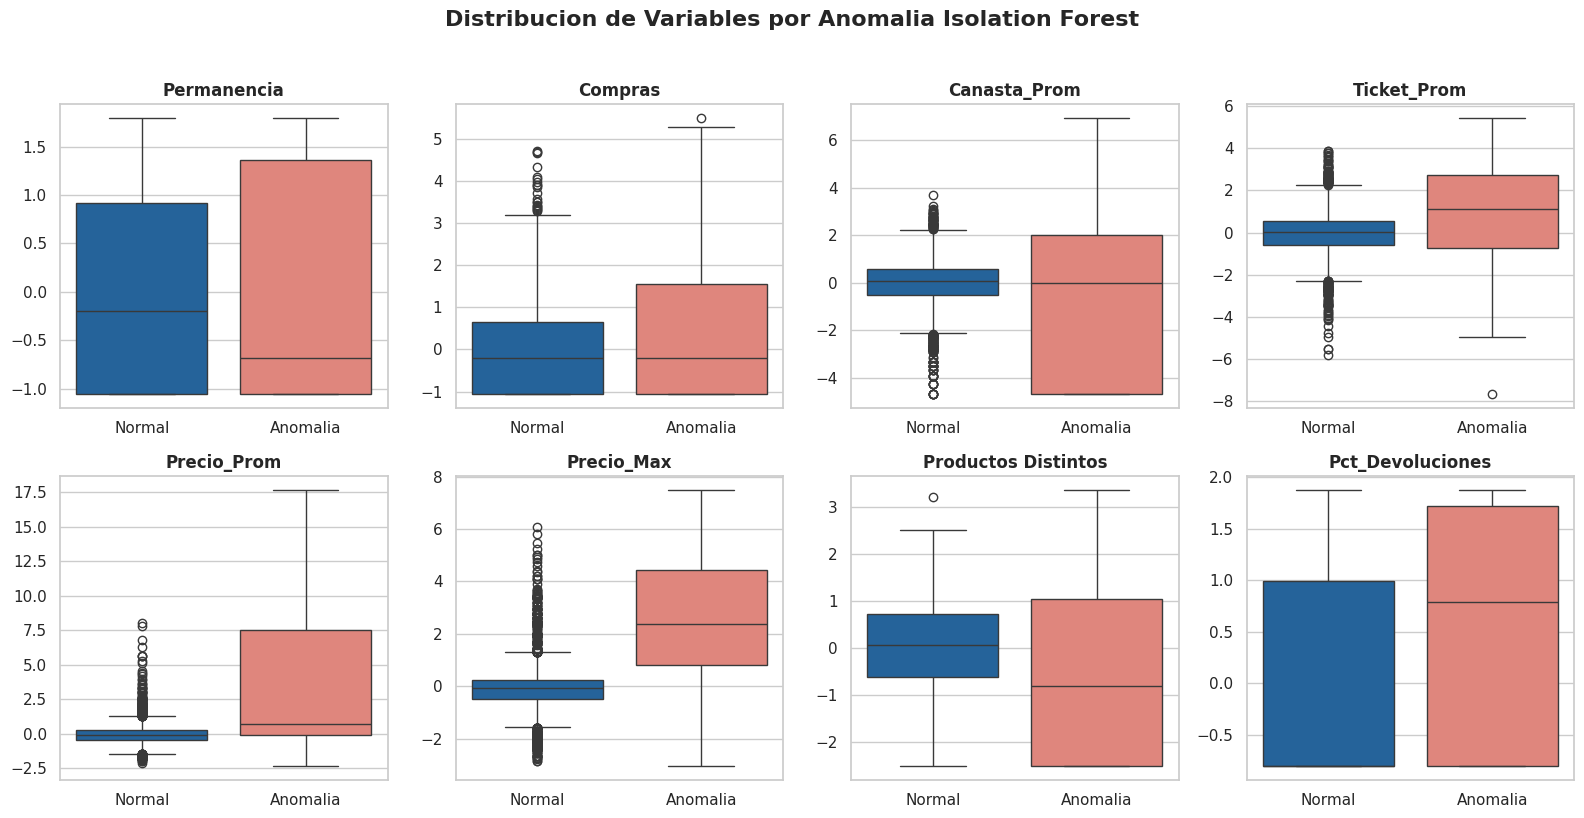

In [35]:
# Boxplots comparando la distribucion de cada variable entre clientes normales y anomalias
n_cols = 4
n_rows = int(np.ceil(len(cols_perfil) / n_cols))

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()

fig.suptitle(
    'Distribucion de Variables por Anomalia Isolation Forest',
    fontsize=16,
    fontweight='bold',
    y=1.02,
)

for ax, col in zip(axes, cols_perfil):
    sns.boxplot(data=df_resultados, x='anomalia_isof', y=col, ax=ax, hue='anomalia_isof', palette={0: '#1164ad', 1: '#ef796d'}, legend=False)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Normal', 'Anomalia'])

for ax in axes[len(cols_perfil):]:
    ax.axis('off')

plt.tight_layout()
plt.show()
sns.reset_defaults()


**Comentarios:**

* **Silhouette Score :** El score obtenido (~0.58) es considerablemente mas alto que el de DBSCAN (~0.08), lo cual indica que el grupo de anomalias identificado por Isolation Forest esta mucho mejor separado del resto de los clientes.
* **Porcentaje de anomalias :** Isolation Forest marco unicamente al 1.34% de los clientes (79 de 5,876) como anomalia, un porcentaje mucho mas razonable y accionable para el negocio que el 39.06% de DBSCAN.
* **Perfil promedio :** A diferencia de DBSCAN, los clientes anomalos de Isolation Forest muestran diferencias marcadas frente a los normales, sobre todo en Precio_Prom (+3.46 desviaciones estandar) y Precio_Max (+2.52), ademas de Ticket_Prom (+0.91) y Pct_Devoluciones (+0.54). Esto describe un grupo de clientes que compran productos considerablemente mas caros de lo usual y/o que tienen tasas de devolucion elevadas, un patron mucho mas claro y accionable que el de DBSCAN.
* **Conclusion :** Isolation Forest logra aislar un grupo pequeño y bien diferenciado de clientes atipicos, en lugar de simplemente etiquetar como ruido a los clientes en zonas de baja densidad. Esto lo hace mas adecuado que DBSCAN para la tarea especifica de deteccion de anomalias sobre este conjunto de datos.


# Comparación de Evaluación

In [36]:
# Tabla resumen comparando ambos modelos de deteccion de anomalias
resumen_comparacion = pd.DataFrame({
    'Silhouette Score' : [sil_score, sil_score_isof],
    'Anomalias Detectadas' : [df_resultados['anomalia_dbscan'].sum(), df_resultados['anomalia_isof'].sum()],
    'Porcentaje Anomalias' : [df_resultados['anomalia_dbscan'].mean() * 100, df_resultados['anomalia_isof'].mean() * 100],
}, index=['DBSCAN', 'Isolation Forest']).round(2)

resumen_comparacion


,Silhouette Score,Anomalias Detectadas,Porcentaje Anomalias
DBSCAN,0.08,2295,39.06
Isolation Forest,0.58,79,1.34


In [37]:
# Cuantos clientes fueron marcados como anomalia por ambos modelos, solo uno, o ninguno
tabla_cruzada = pd.crosstab(
    df_resultados['anomalia_dbscan'].map({0: 'Normal', 1: 'Anomalia'}),
    df_resultados['anomalia_isof'].map({0: 'Normal', 1: 'Anomalia'}),
    rownames=['DBSCAN'],
    colnames=['Isolation Forest'],
)
tabla_cruzada


Isolation Forest,Anomalia,Normal
DBSCAN,,
Anomalia,79,2216
Normal,0,3581


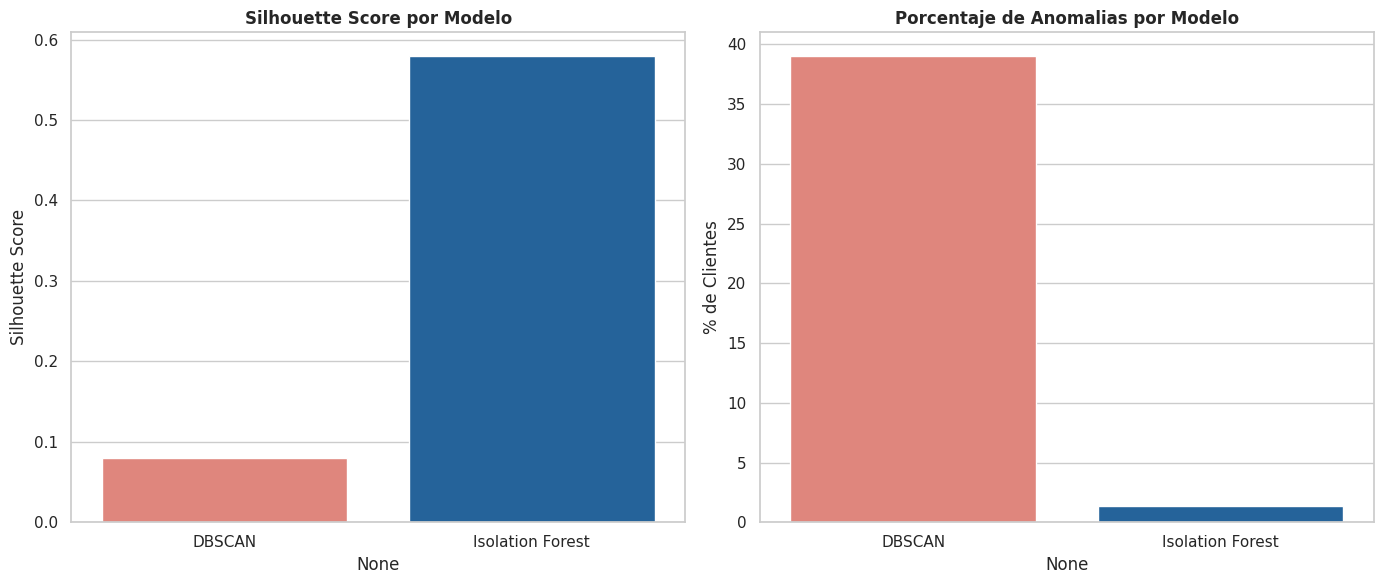

In [38]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    x=resumen_comparacion.index,
    y=resumen_comparacion['Silhouette Score'],
    hue=resumen_comparacion.index,
    palette={'DBSCAN': '#ef796d', 'Isolation Forest': '#1164ad'},
    legend=False,
    ax=axes[0],
)
axes[0].set_title('Silhouette Score por Modelo', fontweight='bold')
axes[0].set_ylabel('Silhouette Score')

sns.barplot(
    x=resumen_comparacion.index,
    y=resumen_comparacion['Porcentaje Anomalias'],
    hue=resumen_comparacion.index,
    palette={'DBSCAN': '#ef796d', 'Isolation Forest': '#1164ad'},
    legend=False,
    ax=axes[1],
)
axes[1].set_title('Porcentaje de Anomalias por Modelo', fontweight='bold')
axes[1].set_ylabel('% de Clientes')

plt.tight_layout()
plt.show()
sns.reset_defaults()


**Comentarios:**

* **Silhouette Score :** Isolation Forest (~0.58) supera ampliamente a DBSCAN (~0.08). El grupo de anomalias de Isolation Forest esta mucho mejor definido y separado del resto de los clientes.
* **Porcentaje de anomalias :** DBSCAN marca al 39.06% de los clientes como ruido, mientras que Isolation Forest marca solo al 1.34%. Un porcentaje tan alto como el de DBSCAN es poco util para el negocio, ya que no permite priorizar acciones sobre un grupo reducido y manejable de clientes.
* **Coincidencia entre modelos :** La tabla cruzada muestra que las 79 anomalias detectadas por Isolation Forest son un subconjunto de los clientes que DBSCAN ya marcaba como ruido (ningun cliente clasificado como normal por DBSCAN fue marcado como anomalia por Isolation Forest). Esto sugiere que Isolation Forest logra aislar, dentro del amplio grupo de ruido de DBSCAN, a los casos verdaderamente extremos.
* **Conclusion final :** Para esta tarea de deteccion de anomalias en clientes, Isolation Forest es el modelo mas adecuado: obtiene un silhouette score mucho mayor, identifica un porcentaje de anomalias mas razonable y accionable, y su perfil de anomalias (precios promedio y maximos elevados, alta tasa de devoluciones) es mucho mas interpretable desde el punto de vista de negocio. DBSCAN resulta mas util como herramienta de segmentacion general (encontro un cluster mayoritario coherente), pero no como detector de anomalias por si solo, dado que su nocion de "ruido" es demasiado amplia y poco discriminativa.
